<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/conspiraciones/llms-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Funcionalidades de LLMs

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html). Consiste en una colección de textos extraidos de Telegram anotados manualmente como mensajes "críticos" (`CRITICAL`) frente a "conspirativos" (`CONSPIRACY`).

En el siguiente código, utilizamos la biblioteca [Hugging Face](https://huggingface.co/) para realizar diversas tareas con modelos de lenguaje. En particular, aprovecharemos las utilidades de [`transformers`](https://huggingface.co/docs/transformers/index) para usar modelos de lenguaje. [Aquí](https://huggingface.co/docs/transformers/main/en/task_summary) se puede encontrar una lista amplia de tareas que se pueden resolver con [`transformers`](https://huggingface.co/docs/transformers/index).

Parte del código está basado en los ejemplos del libro:

> [**Hands-On Large Language Models**](https://www.oreilly.com/library/view/hands-on-large-language/9781098150969/)  
by Jay Alammar, Maarten Grootendorst  
Released September 2024  
Publisher(s): O'Reilly Media, Inc.  
ISBN: 9781098150969

Y en los tutoriales de [Hugging Face](https://huggingface.co/).

Se recomienda usar el _backend_ de TPU para ejecutar este ejemplo en Google Colab gratuito.


## Carga de datos

In [1]:
import gdown
import pandas as pd


# Descargar el archivo dataset.csv desde Google Drive
url = 'https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH'
output = 'dataset.csv'
gdown.download(url, output, quiet=False)

# Cargar datos
data = pd.read_csv('dataset.csv')
data

Downloading...
From: https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH
To: /content/dataset.csv
100%|██████████| 2.34M/2.34M [00:00<00:00, 19.4MB/s]


,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


## Generación de texto
Para generar texto, debemos cargar un modelo capaz de generar texto, como por ejemplo [`microsoft/Phi-3.5-mini-instruct`](https://huggingface.co/microsoft/Phi-3.5-mini-instruct). Además, necesitamos crear un _tokenizador_ apropiado. Para ello, podemos usar las `auto clases` de HuggingFace, como se explica en [este tutorial](https://huggingface.co/docs/transformers/llm_tutorial).

Podríamos utilizar otros modelos más reducidos, aunque los resultados puede que no sean adecuados. Por ejemplo, [`deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5`](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B).

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/Phi-3.5-mini-instruct"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

A continuación, creamos un [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) para generación de texto, usando el tipo `text-generation`. (El tipo de [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) debe ser uno soportado por el modelo de lenguaje especificado.)

In [3]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Ya podemos enviar mensajes al [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline), que los pasará al modelo cargado en el formato adecuado y obtendremos la salida correspondiente.

In [4]:
# Prompt
messages = [
  {"role": "user",
   "content": "What is a surplus in business?"}
]

# Obtener salida
response = pipe(messages)
print(response)

# Extraer campo de interés
print(response[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': ' A surplus in business refers to the situation where the quantity of a product or service supplied exceeds the quantity demanded at a given price level. This can occur due to various reasons such as overproduction, decreased demand, or pricing issues.\n\nIn economic terms, a surplus is represented by a situation where the supply curve is above the demand curve at a particular price point on a graph. The surplus quantity is the horizontal distance between the two curves at that price level.\n\nWhen a surplus exists, it puts downward pressure on the price of the product or service. This is because sellers, in an attempt to sell their excess inventory, may lower their prices to attract more buyers. As prices decrease, the quantity demanded typically increases, and the surplus begins to diminish until it reaches equilibrium, where the quantity supplied equals the quantity demanded.\n\nIn some cases, businesses may choose to maintain a surplus intentionally, for example

## Conversaciones
Siguiendo una aproximación parecida, podemos interactuar con el agente/modelo en [modo conversación](https://huggingface.co/docs/transformers/conversations). Realmente, la única diferencia es que vamos almacenando la historia del chat (consultas y respuestas) y pasándosela por completo en cada interacción, en el orden recibido y especificando los contenidos (`content`) y roles (`role`) de cada interacción.

In [5]:
# Recuperar chat anterior
chat = [
    {"role": "user","content": "What is a surplus in business?"},  # Petición 1
    {"role": "assistant", "content": response[0]["generated_text"]} # Respuesta 1
]

# Añadir nueva interacción
chat.append({"role": "user", "content": "Why don't you explain this to me like I am an eight-year old?"} # Petición 2
)

# Obtener y mostrar salida
response = pipe(chat)
print(response[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Alright, imagine you have a lemonade stand. You make a lot of lemonade because you think many kids will want to buy it on a hot summer day. But when the day comes, not as many kids come to buy your lemonade as you expected. You have more lemonade left over, which means you have a surplus of lemonade.

Now, having too much lemonade isn't good because you spent time and effort making it, and you might even have to throw some away if it goes bad. So, to sell the leftover lemonade, you might decide to lower the price. When the price is lower, more kids might want to buy it because it's cheaper. This way, you can sell more lemonade and reduce the surplus.

In simple words, a surplus is like having more of something than people want to buy. It can happen when we make too much or when fewer people want to buy it. To fix it, we might have to lower the price to make it more appealing to others. Just like with your lemonade stand, businesses try to avoid surpluses because they can lead to losse

In [6]:
# Añadir nueva interacción
chat.append({"role": "assistant", "content": response[0]["generated_text"]}) # Respuesta 2
chat.append({"role": "user", "content": "Why don't you explain this to me like I'm five?"}) # Petición 3

# Obtener y mostrar salida
response = pipe(chat)
print(response[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Okay, let's imagine you have a box of toy cars. You thought you had enough toy cars for all your friends to play with, but when they come over, not as many friends want to play with your toy cars as you thought. You have extra toy cars that no one is playing with. This is what we call a surplus.

A surplus is like having more toys than friends who want to play with them. It's not good because you might have to give away some toys for free or even throw them away if they get broken.

To make sure your friends want to play with your toy cars, you might decide to make a deal. For example, you could say, "If you bring me two of your toy cars, I'll let you play with one of mine." This way, you can share your toys with your friends and make sure no toys are left unused.

In the same way, businesses have to make sure they don't have too many things that no one wants to buy. If they have a surplus, they might lower the price to make it more interesting for people to buy. This helps them sell 

## Análisis de sentimientos
Para esta tarea, primero creamos un [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) de análisis de sentimientos y cargamos el modelo [`cardiffnlp/twitter-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment).

Este modelo nos ayuda a determinar el sentimiento de un texto, clasificándolo como positivo, negativo o neutral (LABEL_0 -> Negative; LABEL_1 -> Neutral; LABEL_2 -> Positive). Disponemos de multitud de modelos alternativos en el repositorio de [Hugging Face](https://huggingface.co/); por ejemplo, para [análisis de sentimientos en español](https://huggingface.co/models?language=es&other=sentiment-analysis&sort=trending).

In [7]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

La función `analyze_sentiment()` toma una frase como entrada y utiliza el pipeline para obtener la etiqueta de sentimiento y su puntuación de confianza, que devuelve como salida.

In [8]:
def analyze_sentiment(pipe, sentence):
    try:
        response = pipe(sentence)[0]
        return response['label'], response['score']
    except Exception as e:
        print(f"Error analizando el sentimiento para '{sentence}': {e}")
        return "UNKNOWN", 0.0

Finalmente, aplicamos la función `analyze_sentiment()` a cada texto en la columna `text` de nuestro conjunto de datos, almacenando los resultados en un nuevo `DataFrame`. Si un texto es demasiado largo, se trunca a 512 caracteres para evitar errores de procesamiento.

In [9]:
from tqdm import tqdm

sentiment_labels = []
sentiment_scores = []

for text in tqdm(data['text'], desc="Processing Sentiments"):
    truncated_text = text[:512] if len(text) > 512 else text
    sentiment_label, sentiment_score = analyze_sentiment(sentiment_pipe, truncated_text)
    sentiment_labels.append(sentiment_label)
    sentiment_scores.append(sentiment_score)

data_sentiment = pd.DataFrame({
    'text': data['text'],
    'category': data['category'],
    'sentiment_label': [label.replace('LABEL_0', 'Negative').replace('LABEL_1', 'Neutral').replace('LABEL_2', 'Positive') for label in sentiment_labels],
    'sentiment_score': sentiment_scores
})

data_sentiment

Processing Sentiments: 100%|██████████| 4000/4000 [00:42<00:00, 93.04it/s] 


,text,category,sentiment_label,sentiment_score
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,Negative,0.609890
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,Negative,0.791545
2,2021 : They wanted to know your vaccination st...,CRITICAL,Negative,0.659615
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,Neutral,0.511057
4,Proof has emerged showing that death from Wuha...,CRITICAL,Negative,0.484783
...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL,Negative,0.865195
3996,I personally do n’t believe Putin would set of...,CONSPIRACY,Negative,0.528019
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL,Neutral,0.509923
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL,Negative,0.583312


Podemos observar la distribución de valores de sentimiento en el conjunto de datos.

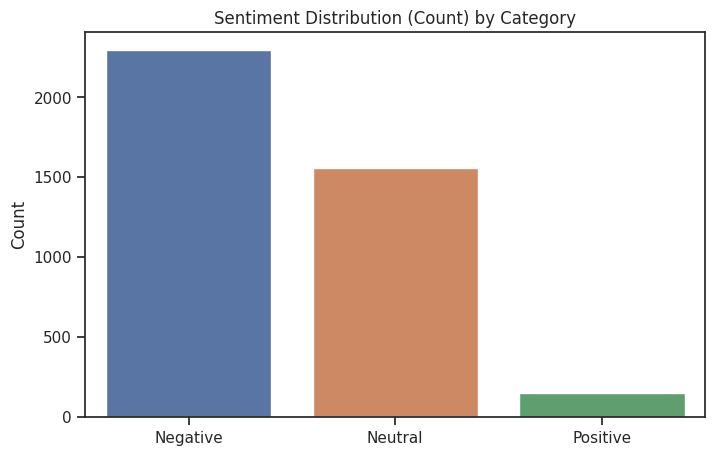

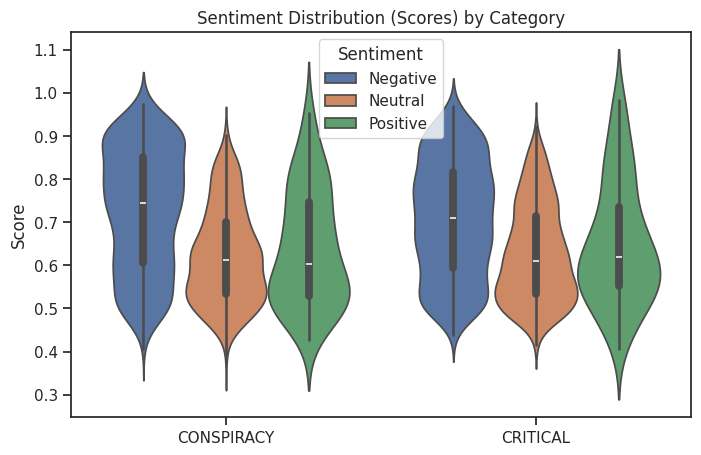

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.countplot(data=data_sentiment, x='sentiment_label', hue='sentiment_label', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Distribution (Count) by Category')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.violinplot(data=data_sentiment, x='category', y='sentiment_score', hue='sentiment_label')
plt.title('Sentiment Distribution (Scores) by Category')
plt.xlabel('')
plt.ylabel('Score')
plt.legend(title='Sentiment')
plt.show()


## Reconocimiento de entidades
El reconocimiento de entidades con nombre (NER, por sus siglas en inglés) es una tarea de clasificación de _tokens_ que busca identificar y clasificar entidades mencionadas en un texto en categorías predefinidas, como personas, organizaciones, ubicaciones, etc. En este caso, utilizaremos el modelo [`bert-base-NER`](https://huggingface.co/dslim/bert-base-NER), que está optimizado para estas tareas.

(Existen otras tareas de clasificación de _tokens_, ver [aquí](https://huggingface.co/docs/transformers/main/en/task_summary#token-classification).)

In [11]:
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Utilizamos el `pipeline` anterior para extraer entidades del primer mensaje del conjunto de datos.

In [12]:
text = data['text'].values[0]
response = ner_pipeline(text)
preds = [
    {
        "entity": prediction["entity"],
        "score": round(prediction["score"], 4),
        "index": prediction["index"],
        "word": prediction["word"],
        "start": prediction["start"],
        "end": prediction["end"],
    }
    for prediction in response
]
print(text)
print(pd.DataFrame(preds))

THIS IS MASSIVE Australian Senator Malcolm Roberts exposes nanotech found in the Covid ‘ vaccines ’ and says they are genocide . He is the first politician to expose this !   SHARE https :// t . me / LauraAbolichannel 
   entity   score  index        word  start  end
0  B-MISC  0.9838      8  Australian     16   26
1   B-PER  0.9997     10     Malcolm     35   42
2   I-PER  0.9996     11     Roberts     43   50
3  B-MISC  0.9917     20          Co     81   83
4  I-MISC  0.8605     21       ##vid     83   86
5   I-PER  0.3427     53         ##A    205  206


## Clasificación con LLMs

Ahora, utilizaremos el modelo de lenguaje de OpenAI, ChatGPT, para clasificar textos en dos categorías: `CONSPIRACY` o `CRITICAL`. Para acceder a este modelo, se utiliza la biblioteca [`openai`](https://platform.openai.com/docs/guides/text-generation), que se conecta a la API remota de OpenAI (**de pago**). El procedimiento es el siguiente:

- Primero, se solicita al usuario que introduzca su clave de API de OpenAI para autenticar las solicitudes al servicio y se inicia el cliente.
- Después, se define una función llamada `classify_text_with_chatgpt` que toma un texto como entrada y utiliza el modelo de lenguaje para clasificarlo. La función envía una solicitud al modelo con un prompt que le pide clasificar el texto en una de las dos categorías.
- Si la clasificación es exitosa, se devuelve la categoría; de lo contrario, se maneja cualquier excepción y se devuelve `UNKNOWN`. Finalmente, se aplica esta función a cada texto en la columna 'text' de los datos, almacenando los resultados en un nuevo DataFrame llamado `data_classification`.

In [33]:
from openai import OpenAI
import getpass

# Solicitar la clave de API de OpenAI al usuario
my_api_key = getpass.getpass("Por favor, introduce tu clave de API de OpenAI: ")

# Inicializar cliente
client = OpenAI(api_key=my_api_key)

# Función para clasificar texto utilizando ChatGPT
def classify_text_with_chatgpt(text):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{
                "role": "developer",
                "content": f"Classify the following text as CONSPIRACY or CRITICAL: {text}. Ensure that you use exactly and only one of these two labels!"}]
        )
        classification = response.choices[0].message.content.strip()
        return classification
    except Exception as e:
        print(f"Error while classifying the text '{text}': {e}")
        return "UNKNOWN"

# Aplicar clasificación a cada texto en la columna 'text'
# (limitado a los `limit` primeros mensajes)
classifications = []
limit = 25

for text in tqdm(data['text'][:limit], desc="Classifying texts"):
    classification = classify_text_with_chatgpt(text)
    classifications.append(classification)

# Crear DataFrame con los resultados
data_classification = pd.DataFrame({
    'text': data['text'][:limit],
    'real_category': data['category'][:limit],
    'llm_classification': classifications
})

data_classification

Por favor, introduce tu clave de API de OpenAI: ··········


Classifying texts: 100%|██████████| 25/25 [00:09<00:00,  2.73it/s]


,text,real_category,llm_classification
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,CONSPIRACY
2,2021 : They wanted to know your vaccination st...,CRITICAL,CONSPIRACY
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL,CONSPIRACY
5,"Joe Biden , who told Americans last year , “ Y...",CRITICAL,CRITICAL
6,""" 1861 for a number of black - magick - relate...",CONSPIRACY,CONSPIRACY
7,WHAT THE HELL HAVE THEY DONE ? FOREIGN PARTICL...,CRITICAL,CONSPIRACY
8,Joe Biden ’s Commerce Secretary has claimed th...,CRITICAL,CRITICAL
9,""" COVID : ALLEGED DOCUMENT PREDICTING THE FREN...",CRITICAL,CONSPIRACY


Sobre estas predicciones, se pueden calcular las métricas habituales.

              precision    recall  f1-score   support

  CONSPIRACY       0.53      1.00      0.69        10
    CRITICAL       1.00      0.40      0.57        15

    accuracy                           0.64        25
   macro avg       0.76      0.70      0.63        25
weighted avg       0.81      0.64      0.62        25



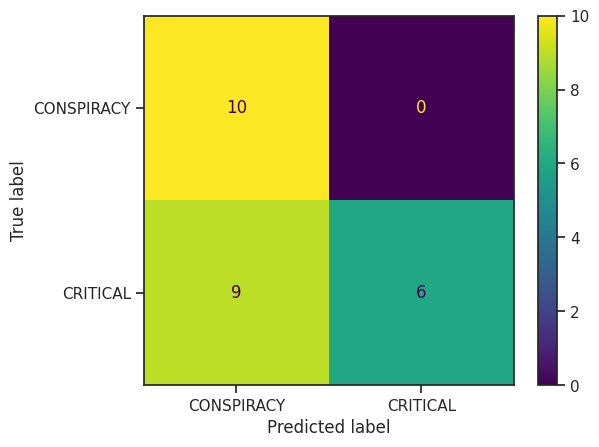

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(
    data_classification['real_category'],
    data_classification['llm_classification']))

cm = confusion_matrix(
    data_classification['real_category'],
    data_classification['llm_classification'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CONSPIRACY', 'CRITICAL'])
disp.plot()

## Modelado de temas
Para _topic modeling_, podemos utilizar la biblioteca [`BERTopic`](https://maartengr.github.io/BERTopic/index.html), que implementa las siguientes etapas:

- Codificación de _tokens_
- Reducción de dimensionalidad
- Agrupamiento en temas
- Descripción de temas

En primer lugar, necesitamos instalar [`BERTopic`](https://maartengr.github.io/BERTopic/index.html). Puede que Colab sugiera reiniciar el entorno, pero no es conveniente hacerlo.

In [15]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.2 MB/s eta 0:00:00


A continuación, tomamos la lista de textos sobre la que queremos extraer los temas, creamos el modelo de _topics_ con [`BERTopic()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic) y lo ajustamos a estos textos con [`fit_transform()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.fit_transform).

Adicionalmente, se puede incluir preprocesamiento específico, como por ejemplo eliminación de palabras sin significado (_stop words_), a través de [`CountVectorizer()`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) de [`scikit-learn`](https://scikit-learn.org/stable/index.html).

In [16]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

docs = data['text'].tolist()

topic_model = BERTopic(
    vectorizer_model=CountVectorizer(stop_words="english"),
    language="english",
    calculate_probabilities=True)

topics, probabilities = topic_model.fit_transform(docs)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[`BERTopic`](https://maartengr.github.io/BERTopic/index.html) incluye numerosas utilidades para analizar los resultados de la extracción. Los más interesantes son la lista de _topics_ y la lista de mensajes con su _topic_ asociado.

In [17]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1570,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...
1,0,102,0_pfizer_trial_fda_documents,"[pfizer, trial, fda, documents, data, moderna,...",[Updated report of SARS - COV - 2 vaccine reac...
2,1,98,1_children_child_fda_schedule,"[children, child, fda, schedule, childhood, ag...",[America Is Now the Only Country in the World ...
3,2,88,2_ukraine_russia_putin_russian,"[ukraine, russia, putin, russian, ukrainian, w...",[The conflict unfolding in Ukraine is deeply t...
4,3,86,3_sir_christopher_uk_public,"[sir, christopher, uk, public, police, vaccine...","[Dear [ insert MP ] , On Tuesday 29th March 20..."
...,...,...,...,...,...
71,70,12,70_lockdown_lockdowns_shutdowns_pandemic,"[lockdown, lockdowns, shutdowns, pandemic, ext...",[A new study out of the renowned Johns Hopkins...
72,71,11,71_pilot_pilots_flight_airline,"[pilot, pilots, flight, airline, tang, crew, a...","["" Elephant in the Cockpit : Pilot Reveals Wor..."
73,72,11,72_eu_european_ema_commission,"[eu, european, ema, commission, leaked, emails...","[Our recent article by Meryl Nass , MD on the ..."
74,73,10,73_transplant_kidney_boy_old,"[transplant, kidney, boy, old, surgery, refuse...",[Duke University denies kidney transplant to 1...


In [18]:
document_info = topic_model.get_document_info(docs)
document_info

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.838541,False
1,“ I ’m deeply concerned that the push to vacci...,1,1_children_child_fda_schedule,"[children, child, fda, schedule, childhood, ag...",[America Is Now the Only Country in the World ...,children - child - fda - schedule - childhood ...,1.000000,False
2,2021 : They wanted to know your vaccination st...,26,26_canada_canadian_premier_alberta,"[canada, canadian, premier, alberta, euthanasi...","[BREAKING ! As of Oct 1 , COVID medical tyrann...",canada - canadian - premier - alberta - euthan...,0.013092,False
3,Anthony Fauci once again defended brutal Chine...,15,15_fauci_rand_anthony_paul,"[fauci, rand, anthony, paul, summit, news, car...",[Senator Rand Paul declared Wednesday that Ant...,fauci - rand - anthony - paul - summit - news ...,1.000000,False
4,Proof has emerged showing that death from Wuha...,-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.786643,False
...,...,...,...,...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,19,19_australia_australians_nsw_unvaccinated,"[australia, australians, nsw, unvaccinated, au...",[You wo n’t see this on the evening news . New...,australia - australians - nsw - unvaccinated -...,0.436189,False
3996,I personally do n’t believe Putin would set of...,2,2_ukraine_russia_putin_russian,"[ukraine, russia, putin, russian, ukrainian, w...",[The conflict unfolding in Ukraine is deeply t...,ukraine - russia - putin - russian - ukrainian...,0.382669,False
3997,Pfizer lied . We know that . There 's no doubt...,0,0_pfizer_trial_fda_documents,"[pfizer, trial, fda, documents, data, moderna,...",[Updated report of SARS - COV - 2 vaccine reac...,pfizer - trial - fda - documents - data - mode...,1.000000,False
3998,""" It is utterly bizarre and inexplicable - Dr....",-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.834672,False


Podemos combinar los resultados de la extracción con la información disponible; por ejemplo, las etiquetas de clasificación de cada texto.

In [19]:
document_info['category'] = data['category']
document_info

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.838541,False,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,1,1_children_child_fda_schedule,"[children, child, fda, schedule, childhood, ag...",[America Is Now the Only Country in the World ...,children - child - fda - schedule - childhood ...,1.000000,False,CRITICAL
2,2021 : They wanted to know your vaccination st...,26,26_canada_canadian_premier_alberta,"[canada, canadian, premier, alberta, euthanasi...","[BREAKING ! As of Oct 1 , COVID medical tyrann...",canada - canadian - premier - alberta - euthan...,0.013092,False,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,15,15_fauci_rand_anthony_paul,"[fauci, rand, anthony, paul, summit, news, car...",[Senator Rand Paul declared Wednesday that Ant...,fauci - rand - anthony - paul - summit - news ...,1.000000,False,CRITICAL
4,Proof has emerged showing that death from Wuha...,-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.786643,False,CRITICAL
...,...,...,...,...,...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,19,19_australia_australians_nsw_unvaccinated,"[australia, australians, nsw, unvaccinated, au...",[You wo n’t see this on the evening news . New...,australia - australians - nsw - unvaccinated -...,0.436189,False,CRITICAL
3996,I personally do n’t believe Putin would set of...,2,2_ukraine_russia_putin_russian,"[ukraine, russia, putin, russian, ukrainian, w...",[The conflict unfolding in Ukraine is deeply t...,ukraine - russia - putin - russian - ukrainian...,0.382669,False,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,0,0_pfizer_trial_fda_documents,"[pfizer, trial, fda, documents, data, moderna,...",[Updated report of SARS - COV - 2 vaccine reac...,pfizer - trial - fda - documents - data - mode...,1.000000,False,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",-1,-1_covid_vaccine_people_https,"[covid, vaccine, people, https, nt, new, vacci...",[HOSPITAL HOMICIDE : Newborn baby DIES from “ ...,covid - vaccine - people - https - nt - new - ...,0.834672,False,CRITICAL


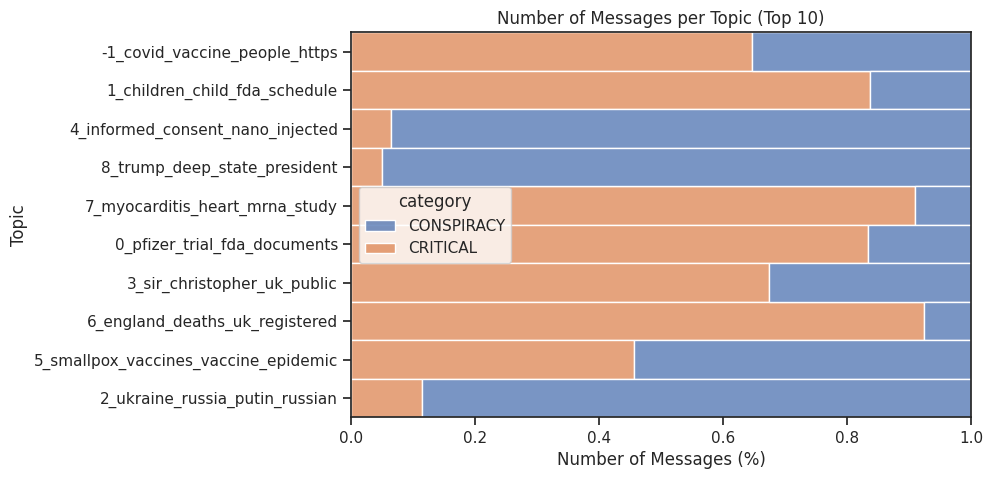

In [20]:
# Limitar a los primeros 10 temas
top_10_topics = topic_info['Topic'][:10].tolist()
document_info_top_10 = document_info[document_info['Topic'].isin(top_10_topics)]

# Crear gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.histplot(data=document_info_top_10, y='Name', hue='category', multiple="fill", discrete=True)
plt.title('Number of Messages per Topic (Top 10)')
plt.ylabel('Topic')
plt.xlabel('Number of Messages (%)')
plt.show()

También es posible clasificar un texto que no está en el conjunto de entrenamiento usando [`transform()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.transform).

In [21]:
text_to_classify = "COVID was designed to inject kids with mental-control vaccines."
predicted_topic, probabilities = topic_model.transform([text_to_classify])
print(f"Predicted topic for the text: {predicted_topic}")

Predicted topic for the text: [np.int64(1)]


Otras visualizaciones interesantes son, por ejemplo:

- La ubicación de los _topics_ en un plano 2D [`visualize_topics()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_topics)
- Los términos más relevantes de cada _topic_ [`visualize_barchart()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_barchart)
- La jerarquía considerando la granularidad de los _topics [`visualize_hierarchy()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_hierarchy)

In [22]:
topic_model.visualize_topics()

In [23]:
topic_model.visualize_barchart()

In [24]:
topic_model.visualize_hierarchy()

Existen métodos alternativos para la obtención de las representaciones de los _topics_. Una de ellas es recurrir a un agente conversacional para que nos dé una posible descripción de cada _topic_.

A continuación, se muestra un ejemplo con ChatGPT. Para ello, es necesario configurar el modelo de representación que usará [`BERTopic`](https://maartengr.github.io/BERTopic/index.html) como un modelo [`OpenAI`](https://maartengr.github.io/BERTopic/api/representation/openai.html) y especificar la clave de conexión a la API. Adicionalmente, es necesario usar el _tokenizador_ correcto, para lo cual puede utilizarse [`tiktoken`](https://github.com/openai/tiktoken).

In [25]:
!pip install tiktoken

In [26]:
import tiktoken
from bertopic.representation import OpenAI
import openai

def configure_representation_model_OpenAI(api_key: str, model: str = "gpt-4o-mini"):
    # Tokenizer
    tokenizer= tiktoken.encoding_for_model(model)

    # Modelo de representación
    client = openai.OpenAI(api_key=api_key)
    representation_model = OpenAI(
        client,
        model=model,
        delay_in_seconds=2,
        chat=True,
        nr_docs=25,
        doc_length=100,
        tokenizer=tokenizer
    )

    return representation_model

Una vez configurado, el modelo [`BERTopic()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic) con representación obtenida con ChatGPT se crea de forma análoga a la anterior y se entrena con [`fit()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.fit).

In [27]:
from bertopic.representation import KeyBERTInspired

representation_model = {
    "Representation KeyBERT":    KeyBERTInspired(),
    "Representation OpenAI":     configure_representation_model_OpenAI(my_api_key)
}

topic_model = BERTopic(
    representation_model=representation_model,
    vectorizer_model=CountVectorizer(stop_words="english"),
    language="english",
    calculate_probabilities=True)

topics, probabilities = topic_model.fit_transform(docs)

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representation KeyBERT,Representation OpenAI,Representative_Docs
0,-1,1597,-1_covid_https_vaccine_people,"[covid, https, vaccine, people, nt, new, 19, v...","[vaccination, vaccine, vaccinated, pandemic, v...",[Vaccine-related controversies],[Question : Is the New Zealand government guil...
1,0,95,0_pfizer_trial_fda_documents,"[pfizer, trial, fda, documents, moderna, data,...","[pfizer, vaccine, pfizergate, vaccines, vaccin...",[Pfizer vaccine controversies],[Updated report of SARS - COV - 2 vaccine reac...
2,1,89,1_ukraine_russia_putin_russian,"[ukraine, russia, putin, russian, ukrainian, w...","[ukraine, ukrainian, putin, russia, russians, ...",[Russia Ukraine Conflict],[The conflict unfolding in Ukraine is deeply t...
3,2,88,2_sir_christopher_uk_mp,"[sir, christopher, uk, mp, public, police, vac...","[vaccine, vaccinated, vaccines, covid, nhs, co...",[COVID Vaccine Controversies],"[Dear [ insert MP ] , On Tuesday 29th March 20..."
4,3,81,3_children_fda_kids_schedule,"[children, fda, kids, schedule, childhood, bab...","[vaccines, vaccine, vaccinating, vaccinated, c...",[COVID-19 Vaccination Controversies],[America Is Now the Only Country in the World ...
...,...,...,...,...,...,...,...
69,68,12,68_odysee_live_trovo_superchats,"[odysee, live, trovo, superchats, entropystrea...","[vaccine, vaccines, live, warns, watch, wapo, ...",[Vaccine controversy discussions],[I'M LIVE NOW ! Title : Hot Mic Catches Israel...
70,69,12,69_pilot_pilots_flight_airline,"[pilot, pilots, flight, airline, tang, crew, a...","[pilots, pilot, airline, airlines, airplane, f...",[Vaccine mandates in aviation],"["" Elephant in the Cockpit : Pilot Reveals Wor..."
71,70,12,70_lockdown_lockdowns_pandemic_shutdowns,"[lockdown, lockdowns, pandemic, shutdowns, ext...","[lockdowns, lockdown, pandemic, shutdowns, ove...",[Impact of lockdowns],[A new study out of the renowned Johns Hopkins...
72,71,11,71_transplant_kidney_boy_old,"[transplant, kidney, boy, old, year, surgery, ...","[unvaccinated, transplant, vaccination, transp...",[Vaccination and Transplants],[Duke University denies kidney transplant to 1...
